# Photometric redshifts

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/photo_z.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/photo_z.ipynb)

Estimating the redshift of a galaxy (a proxy for its distance) from its
magnitudes alone, also known as a photometric redshift (photo-$z$), is the
problem `lazy` was first built for. In this tutorial, we predict redshift
PDFs for the galaxies of the LSST DESC Data Challenge 1, score them with the
metrics of the challenge, and compare two models on the hardest galaxies.
We then build a training set biased the way real spectroscopic samples are,
and show how much a small representative sample added to the context
repairs it.

## Setup

When the notebook runs on Google Colab, the cell below installs the package
with the TabPFN and TabICL backends and the `qp` extra. Elsewhere, the
package needs to be installed first with
`pip install 'lazy-tfm[tabpfn,tabicl,qp]'`. On Colab, choose
*Runtime → Change runtime type → T4 GPU*.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn,tabicl,qp]'
    pass

In [2]:
import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables

import lazy
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 299792458  # One seed for everything random
rng = np.random.default_rng(SEED)

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

We use the catalog of the LSST DESC Photo-$z$ Data Challenge 1 (DC1;
[Schmidt, Malz et al. 2020](https://arxiv.org/abs/2001.03621)), in which a
dozen photo-$z$ codes were compared on the same simulated galaxies.
`datasets.fetch_dc1` downloads it (about 1 GB, checksummed) the first time
it is called, and with `split=True` it returns the training and test sets of
the challenge itself. The model sees the features that
`features("mag-color")` builds, which are the $i$-band magnitude and the five
adjacent colors ($u-g$, $g-r$, ...), with their errors propagated in
quadrature (see
[Demo datasets](https://lazy-tfm.readthedocs.io/en/latest/guide/datasets.html)).
The whole training set of 43,486 galaxies is the context, and we take a
random 5,000 of the 390,990 test galaxies to keep this tutorial quick.

In [3]:
train, test = datasets.fetch_dc1(split=True)

X_train = train.features("mag-color")
z_train = train.redshift
rows = rng.choice(len(test), size=5_000, replace=False)
X_test = test.features("mag-color").iloc[rows]
z_test = test.redshift[rows]

print(f"{len(X_train):,} context rows, {len(X_test):,} test rows")
X_train.head()

43,486 context rows, 5,000 test rows


,I,U-G,G-R,R-I,I-Z,Z-Y,IERR,U-GERR,G-RERR,R-IERR,I-ZERR,Z-YERR
0,16.209900,0.923601,0.464600,0.233200,0.148600,0.188100,0.0050,0.007071,0.007071,0.007071,0.007071,0.007071
1,16.528799,1.328299,0.765900,0.450102,0.273699,0.302000,0.0050,0.007142,0.007071,0.007071,0.007071,0.007071
2,20.628300,0.627401,0.181999,0.200300,-0.026899,0.127199,0.0051,0.008500,0.007142,0.007142,0.007284,0.008246
3,19.056801,0.993200,0.315498,0.181900,-0.031898,0.102200,0.0050,0.007433,0.007071,0.007071,0.007071,0.007142
4,20.437099,0.550201,0.121500,0.129000,-0.042801,0.029600,0.0051,0.007951,0.007142,0.007142,0.007284,0.008169


## Redshift PDFs

We fit the default model, TabPFN-3.5, with the training galaxies as its
context. `fit` trains no weights; it encodes the context with the network
and keeps the result as a key/value cache, which every prediction then
reuses (the
[basic usage](https://lazy-tfm.readthedocs.io/en/latest/tutorials/basic_usage.html)
tutorial explains what `fit` and `predict_proba` do). We ask for the PDFs on
the grid of the challenge, `datasets.DC1_GRID` (200 bins over
$0 \le z \le 2$), so that the numbers below are comparable with those of
the challenge.

In [4]:
grid = datasets.DC1_GRID
model = lazy.LazyModel(random_state=SEED)
model.fit(X_train, z_train)
pdfs = model.predict_proba(X_test, grid)

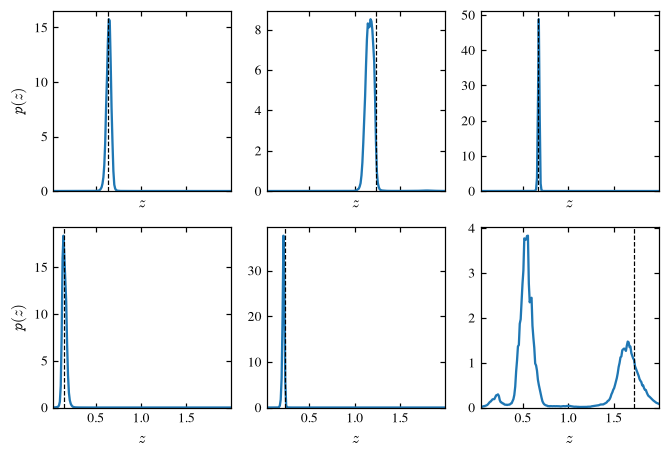

In [5]:
axes = plotting.plot_pdfs(
    grid, pdfs, y_true=z_test, n_objects=6, random_state=SEED
)
for ax in axes:
    if ax.get_xlabel():
        ax.set_xlabel("$z$")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("$p(z)$")

The figure shows the PDFs of six random galaxies, with their true redshifts
as dashed lines. Five of them are narrow, while the last (bottom right) has
two peaks, with its true redshift under the smaller one, since galaxies at
two different redshifts can have similar colors. This
degeneracy between color and redshift is what a single point estimate per
galaxy hides.

## Scoring the PDFs

`metrics.summarize` scores the PDFs with the metrics of the challenge: the
CDE loss, which scores whole PDFs (lower is better); the PIT statistics,
which test calibration; and the bias, scatter and outlier fraction of the
mode (see
[From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html)).
Since photometric redshift errors grow with $1 + z$, the challenge divided
each residual by $1 + z_\mathrm{true}$, and `scale="1+y"` asks for that
convention.

In [6]:
table = metrics.summarize(z_test, grid, pdfs, label="TabPFN-3.5", scale="1+y")
table.T

,0
model,TabPFN-3.5
point_estimate,mode
scale,1+y
n,5000
bias,-0.000225
sigma_mad,0.014025
sigma_iqr,0.014065
outlier_rate,0.0586
outlier_threshold,0.06
outlier_rate_015,0.0204


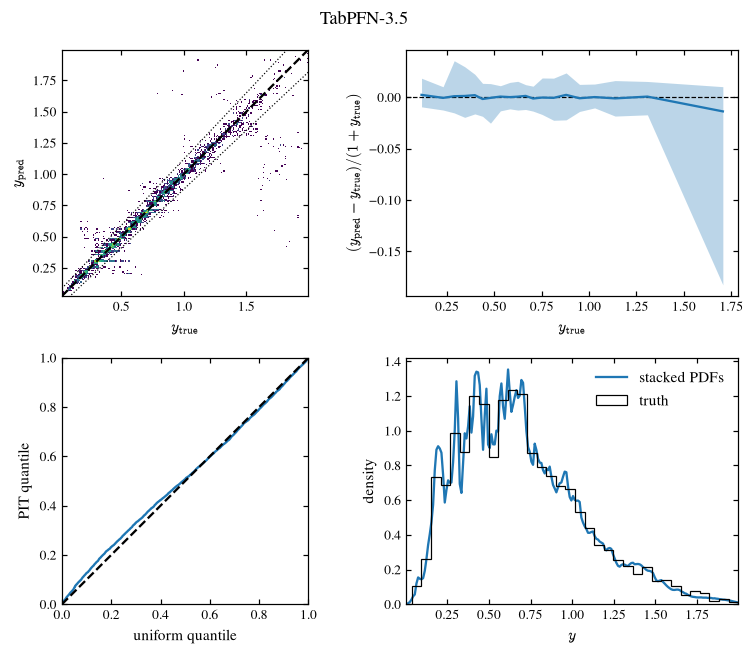

In [7]:
fig = plotting.diagnostic_panel(
    z_test, grid, pdfs, label="TabPFN-3.5", scale="1+y"
)

The figure shows the same quantities. The first panel plots the modes
against the true redshifts, with the outlier cut of the challenge,
$|z_\mathrm{pred} - z_\mathrm{true}| > 0.06\,(1+z_\mathrm{true})$, as dotted
lines (`plotting.plot_actual_vs_predicted(..., outlier_lines=True)` draws
this panel alone). The second shows the running median of the residuals with
its 68% band, the third the PIT quantiles against those of a uniform
distribution, and the last the stacked PDFs against the true redshift
distribution $n(z)$. We see that most galaxies sit inside the outlier cut
(the outlier fraction is 5.86%), that the residuals scatter more widely
above $z \approx 1.3$, and that the PIT quantiles lie close to the
diagonal and the stacked PDFs close to $n(z)$.

## A second model on the hardest galaxies

TabICL is small, BSD-licensed and fast on a CPU. We run it on the same
galaxies with 4 ensemble members instead of the default 8, since caching a
context of this size for 8 members briefly needs about 14 GB of GPU memory,
more than a T4 has to spare.

In [8]:
tabicl = lazy.LazyModel("tabicl", n_estimators=4, random_state=SEED)
tabicl.fit(X_train, z_train)
pdfs_tabicl = tabicl.predict_proba(X_test, grid)

pd.concat(
    [
        table,
        metrics.summarize(
            z_test, grid, pdfs_tabicl, label="TabICL", scale="1+y"
        ),
    ]
).set_index("model").T

model,TabPFN-3.5,TabICL
point_estimate,mode,mode
scale,1+y,1+y
n,5000,5000
bias,-0.000225,-0.000192
sigma_mad,0.014025,0.014807
sigma_iqr,0.014065,0.014894
outlier_rate,0.0586,0.0632
outlier_threshold,0.06,0.06
outlier_rate_015,0.0204,0.0206
median_abs_error,0.009457,0.010038


We find that TabPFN-3.5 gives the lower CDE loss (-14.69 vs. -13.46), the
smaller scatter ($\sigma_\mathrm{IQR}$ of 0.0141 vs. 0.0149) and fewer
outliers (5.86% vs. 6.32%), while TabICL gives the smaller PIT statistics
(a KS statistic of 0.026 vs. 0.036), i.e., slightly better calibrated
PDFs.

To see where the two models differ, we pick six galaxies at random from the
5% whose TabPFN 68% interval (`predict_interval`) is the widest.

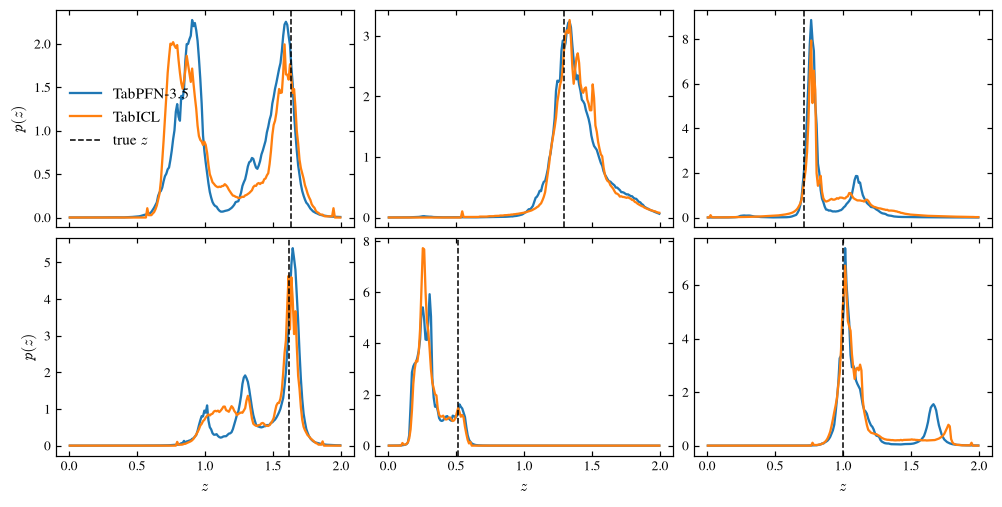

In [9]:
low, high = model.predict_interval(X_test, 0.68).T
width = high - low
hardest = np.flatnonzero(width > np.quantile(width, 0.95))
idx = rng.choice(hardest, size=6, replace=False)

fig, axes = plt.subplots(
    2, 3, figsize=(9, 4.5), sharex=True, layout="constrained"
)
for ax, i in zip(axes.flat, idx):
    ax.plot(grid.centers, pdfs[i], label="TabPFN-3.5")
    ax.plot(grid.centers, pdfs_tabicl[i], label="TabICL")
    ax.axvline(z_test[i], color="k", ls="--", lw=1, label="true $z$")
for ax in axes[-1]:
    ax.set_xlabel("$z$")
for ax in axes[:, 0]:
    ax.set_ylabel("$p(z)$")
axes[0, 0].legend()
plt.show()

The figure shows the PDFs of both models for these six galaxies, with
their true redshifts as dashed lines. Five of the six have two or more
peaks (the top middle one has a single broad peak), and the two models place
the peaks at similar redshifts, although they often weigh them differently
and the TabICL PDFs are noisier. In one of them (bottom middle), the true
redshift lies under a small secondary peak, which is where a point estimate
fails while the PDF still holds the right answer.

## A biased training set

The DC1 training set is drawn like the test set. Real spectroscopic samples
are not: they are bright, incomplete, and truncated in redshift by which
spectral features fall in the observed window. `datasets.fetch_dc1_biased`
builds this case from DC1. It first merges and reshuffles both DC1 files and
cuts them in two. It then runs the first part through a port of the HSC
`GridSelection` of RAIL (`lazy.selection.grid_selection`), which keeps each
galaxy with the HSC PDR2 ratio of spectroscopic to photometric galaxies in
its pixel of $i$-band magnitude and $g-z$ color, below a redshift ceiling
set by the HSC spectra in that pixel, and the galaxies it keeps form the
biased training set. Finally, it divides the second part at random into a
representative calibration sample and a representative test set. Since the
selection keeps a nearly fixed fraction of whatever it sees, the position of
the cut is solved for to give `n_train` training galaxies (35,000 by
default), and since the calibration sample comes out of the hold-out, no
galaxy is both in a context and scored on.

In [10]:
split = datasets.fetch_dc1_biased()
print(split)
split.summary()

SelectionSplit(biased=35,011, calibration=10,000, test=19,383)


,n,median_I,median_z,max_z,frac_I_gt_24
set,,,,,
biased,35011,21.770500,0.470071,1.95103,0.025164
calibration,10000,24.149200,0.644224,1.99794,0.546100
test,19383,24.148300,0.642523,1.99900,0.544756
catalog,434476,24.138201,0.643072,1.99998,0.542269


The table compares each subset with the parent catalog of 434,476
galaxies. We see that the selection moves the median $i$-band magnitude of
the biased set from 24.14 to 21.77 and its median redshift from 0.64 to
0.47, and leaves only 2.5% of its galaxies fainter than $i = 24$ (vs. 54.2%
in the catalog). The calibration and test sets match the catalog in every
column, as they should.

As in our own tests, we compare a context of biased galaxies alone with the
same context plus a small calibration sample. To keep this quick, we draw at
random 10,000 biased galaxies, 1,000 calibration galaxies and 5,000 test
galaxies. The full split (35,011 biased galaxies, up to 10,000 calibration
galaxies and 19,383 test galaxies) runs the same way, at a few times the
cost.

In [11]:
biased = rng.choice(len(split.biased), size=10_000, replace=False)
calibration = rng.choice(len(split.calibration), size=1_000, replace=False)
scored = rng.choice(len(split.test), size=5_000, replace=False)

X_biased = split.biased.features("mag-color").iloc[biased]
z_biased = split.biased.redshift[biased]
X_cal = split.calibration.features("mag-color").iloc[calibration]
z_cal = split.calibration.redshift[calibration]
X_rep = split.test.features("mag-color").iloc[scored]
z_rep = split.test.redshift[scored]

contexts = {
    "biased": (X_biased, z_biased),
    "biased + calibration": (
        pd.concat([X_biased, X_cal]),
        np.concatenate([z_biased, z_cal]),
    ),
}
results, modes = {}, {}
for name, (X, z) in contexts.items():
    biased_model = lazy.LazyModel(random_state=SEED).fit(X, z)
    results[name] = biased_model.predict_proba(X_rep, grid)
    modes[name] = metrics.grid_point_estimates(grid, results[name])["mode"]

# The outlier fraction above z = 1.5, where the biased set is thin.
high = z_rep > 1.5
print(
    f"z > 1.5: {np.mean(z_biased > 1.5):.1%} of the biased context,"
    f" {high.mean():.1%} ({high.sum()}) of the test galaxies"
)
table_biased = pd.concat(
    [
        metrics.summarize(z_rep, grid, p, label=name, scale="1+y")
        for name, p in results.items()
    ]
).set_index("model")[["cde_loss", "sigma_iqr", "bias", "outlier_rate"]]
table_biased["outlier_rate_z_gt_1.5"] = [
    np.mean(np.abs(m[high] - z_rep[high]) > 0.06 * (1 + z_rep[high]))
    for m in modes.values()
]
table_biased

z > 1.5: 0.1% of the biased context, 3.8% (189) of the test galaxies


,cde_loss,sigma_iqr,bias,outlier_rate,outlier_rate_z_gt_1.5
model,,,,,
biased,-13.420088,0.015822,-0.000909,0.0810,0.703704
biased + calibration,-13.830889,0.015184,-0.000426,0.0728,0.582011


We see that adding 1,000 representative galaxies to the 10,000 biased ones
lowers the CDE loss from -13.42 to -13.83, the scatter from 0.0158 to
0.0152 and the outlier fraction from 8.10% to 7.28%. The largest change is
above $z = 1.5$, which holds 0.1% of the biased context but 3.8% of the test
galaxies, and where the outlier fraction falls from 70.4% to 58.2%.

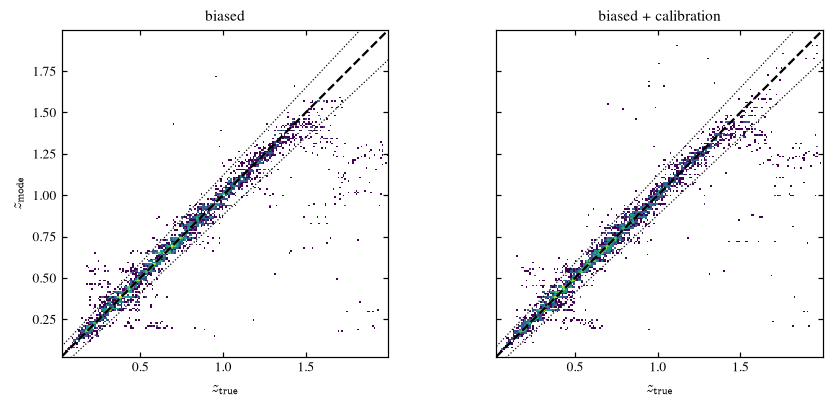

In [12]:
fig, axes = plt.subplots(
    1, 2, figsize=(8, 3.6), sharey=True, layout="constrained"
)
for ax, (name, z_mode) in zip(axes, modes.items()):
    plotting.plot_actual_vs_predicted(z_rep, z_mode, ax=ax, outlier_lines=True)
    ax.set_title(name)
    ax.set_xlabel(r"$z_\mathrm{true}$")
axes[0].set_ylabel(r"$z_\mathrm{mode}$")
axes[1].set_ylabel("")
plt.show()

The figure shows the modes against the true redshifts for the two contexts,
with the outlier cut as dotted lines. With the biased context alone, most
galaxies above $z \approx 1.5$ are placed near $z \approx 1.25$, the
redshifts the selection still covers. The calibration sample moves some of
them back to the diagonal, although many of them remain outliers.
Therefore, even a small representative sample in the context repairs part
of the damage done by the selection, and `split.calibration` holds 10,000
galaxies for trying larger ones.

## PDFs for RAIL

The LSST DESC photo-$z$ pipeline RAIL stores PDFs with the `qp` package.
`predict_distribution` returns the native distributions of the model, and
their `to_qp()` turns them into a `qp.Ensemble`, which needs the `qp` extra.

In [13]:
try:
    import qp  # noqa: F401 - only to check that the extra is installed.
except ImportError:
    print("qp is not installed: pip install 'lazy-tfm[qp]'")
else:
    ensemble = model.predict_distribution(X_test.iloc[:100]).to_qp()
    print(ensemble.npdf, "PDFs, of class", type(ensemble.gen_obj).__name__)

100 PDFs, of class hist_gen


## Next steps

- [Biased training sets](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html#biased-training-sets):
  which model to use with a biased context, and the label-shift correction
  of TabFM.
- [Choosing a model](https://lazy-tfm.readthedocs.io/en/latest/guide/choosing.html):
  which model to choose, and what hardware it needs.
- [Scaling and performance](https://lazy-tfm.readthedocs.io/en/latest/guide/scaling.html):
  contexts larger than the 43,486 galaxies used here.